In [1]:
import h5py
import numpy as np
from scipy.special import stdtrit
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from libra_py import units

%matplotlib inline

In [2]:
def fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename="figure.png", conf_level = 0.95, r2_min = 0.7):

    # Create a 1x1 grid of subplots with a more square-like figure size
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)

    # Loop through each method
    for c, method in enumerate(['IDA']):
        taus = []
        fit_function = fitting_for_method[method]
    
        for icond in iconds:
            try:
                with h5py.File(f'{method}_icond_{icond}/mem_data.hdf', 'r') as F:
                    sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                    md_time = np.array(F['time/data'][:]) * units.au2fs
            except FileNotFoundError:
                print(f"File not found: {method}_icond_{icond}/mem_data.hdf, skipping.")
                continue

            popt, pcov = curve_fit(fit_function, md_time, sh_pop, bounds=([0.0], [np.inf]))
            tau = popt
            residuals = sh_pop - fit_function(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"icond: {icond}, r_squared: {r_squared}, tau: {tau}")  # Print r_squared for each icond

            # Only append tau and plot if r_squared is greater than 0.1        
            if r_squared > r2_min:
                ax.plot(md_time, sh_pop, color='blue', linewidth=2.0)  # Line color is black
                taus.append(tau)
                print(F"plotting this batch, the fitted tau is {tau}")
            else:
                ax.plot(md_time, sh_pop, color='grey', linewidth=2.0) 

        taus = np.array(taus)
        if len(taus) > 0:  # Proceed only if there are valid taus
            ave_tau = np.average(taus)
            s = np.std(taus)            
            N = taus.shape[0]
            #Z = 1.96 - naive value
            Z = stdtrit(N-1, conf_level) # better approach
            print(F"Z = {Z}")
            error_bar = Z * s / np.sqrt(N) 
        
            # Convert timescale to picoseconds (ps)
            ave_tau_ps = ave_tau / 1000
            error_bar_ps = error_bar / 1000
        
            print(f'The timescales for method {method}: \n {ave_tau_ps}+-{error_bar_ps} ps, averaged over {len(taus)} samples')

            ax.plot(md_time, fit_function(md_time, ave_tau - error_bar), ls='--', color="red", linewidth=2.0)
        
            # Increase the linewidth of the solid red line
            ax.plot(md_time, fit_function(md_time, ave_tau), ls='-', color="red", label=f"{method}: {ave_tau_ps:.0f} ± {error_bar_ps:.0f} ps \n \
$R^2$: {r2_min} confidence: {conf_level*100}%", linewidth=4)
        
            ax.plot(md_time, fit_function(md_time, ave_tau + error_bar), ls='--', color="red", linewidth=2.0)
            ax.fill_between(md_time, fit_function(md_time, ave_tau - error_bar), fit_function(md_time, ave_tau + error_bar), color='red', alpha=0.1, linewidth=2.0)

        # Set the same plot settings as before
        ax.tick_params(axis='x', labelsize=24, width=2.5, length=10)
        ax.tick_params(axis='y', labelsize=24, width=2.5, length=10)
        ax.set_xlim(left=-500, right=4001)
        ax.set_ylim(bottom=-0.001, top=0.021)
        ax.set_facecolor('white')

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        ax.set_title(F'{figuretitle}', fontsize=26, pad=20, x=0.45)
        ax.set_xlabel('Time, fs', fontsize=26)
        ax.set_ylabel('Population', fontsize=26)

        ax.legend(fontsize=20, loc='upper left')
        fig.patch.set_facecolor('white')
        ax.set_xticks(np.arange(0, 30001, 10000))
        ax.set_ylim(0, 0.015)
        yticks = np.linspace(0, 0.015, 5)
        #yticklabels = [f"{y:.5f}" for y in yticks]
        
        yticklabels = [f"{y:.3f}" for y in yticks]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=24)
        plt.tight_layout()
        plt.savefig(F'{figurename}', dpi=600)
        plt.show()

In [3]:
# Fitting functions

def exp_func(x, a):
    return 1 - np.exp(-x / a)

def gau_func(x, a):
    return 1 - np.exp(-x**2 / a**2)

icond: 1, r_squared: 0.6097676038339244, tau: [226585.58359121]
icond: 101, r_squared: 0.29184740255681807, tau: [172455.75581701]
icond: 201, r_squared: 0.6553205526101226, tau: [205437.84549225]
icond: 301, r_squared: 0.9049145399667278, tau: [244122.66755899]
plotting this batch, the fitted tau is [244122.66755899]
icond: 401, r_squared: 0.36651312989596474, tau: [245108.72443153]
icond: 501, r_squared: 0.8841276338997816, tau: [370087.03106735]
plotting this batch, the fitted tau is [370087.03106735]
icond: 601, r_squared: -0.22587814396318806, tau: [262921.47172744]
icond: 701, r_squared: 0.855910830179014, tau: [364031.07524997]
plotting this batch, the fitted tau is [364031.07524997]
icond: 801, r_squared: 0.917263179708578, tau: [212078.51730991]
plotting this batch, the fitted tau is [212078.51730991]
icond: 901, r_squared: -0.23914863293651067, tau: [298941.83902818]
Z = 2.353363434801826
The timescales for method IDA: 
 297.57982279655323+-82.8729943487439 ps, averaged over 

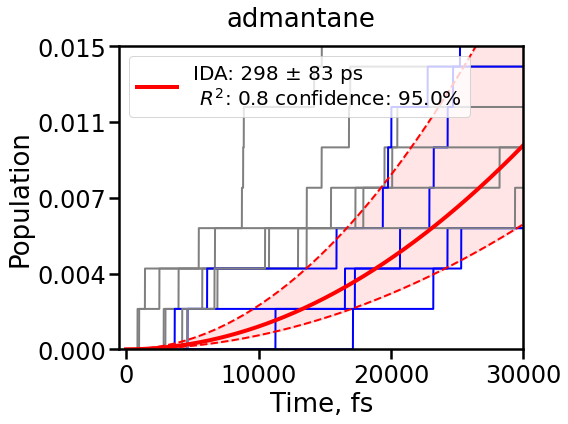

In [4]:
methods = ["IDA"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDA': gau_func } 
figuretitle = "admantane"
figurename = "IDA-gau.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

icond: 1, r_squared: 0.9392721818584915, tau: [2119253.17852462]
plotting this batch, the fitted tau is [2119253.17852462]
icond: 101, r_squared: 0.8945607205360846, tau: [1202644.12697753]
plotting this batch, the fitted tau is [1202644.12697753]
icond: 201, r_squared: 0.8898347662260673, tau: [1750845.7007976]
plotting this batch, the fitted tau is [1750845.7007976]
icond: 301, r_squared: 0.7176151291713797, tau: [2688796.24738882]
icond: 401, r_squared: 0.8533889342324058, tau: [2429878.00729175]
plotting this batch, the fitted tau is [2429878.00729175]
icond: 501, r_squared: 0.6957656052915961, tau: [5497730.39054587]
icond: 601, r_squared: 0.6521706047656877, tau: [2765710.01403066]
icond: 701, r_squared: 0.6449530063506401, tau: [5445867.74745956]
icond: 801, r_squared: 0.8711597919699783, tau: [1952631.92269547]
plotting this batch, the fitted tau is [1952631.92269547]
icond: 901, r_squared: 0.6046036570515456, tau: [3405093.34506039]
Z = 2.1318467813362902
The timescales for me

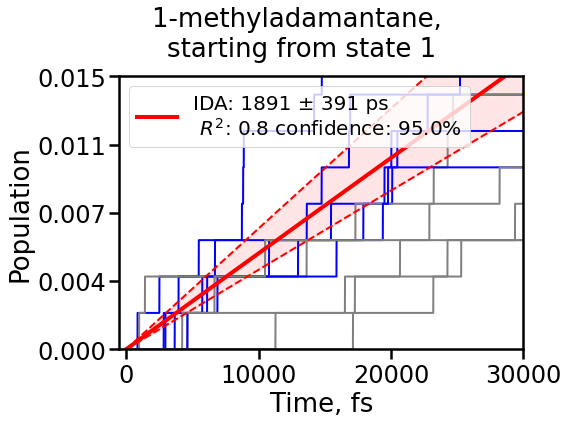

In [5]:
methods = ["IDA"]
iconds = list(range(1, 1000, 100))
fitting_for_method = {'IDA': exp_func } 
figuretitle = "1-methyladamantane, \nstarting from state 1"
figurename = "IDA-exp.png"

fit_namd_data(methods, iconds, fitting_for_method, figuretitle, figurename, conf_level = 0.95, r2_min = 0.8)

In [6]:
import warnings
from libra_py import trpes
%matplotlib inline
warnings.filterwarnings("ignore")  # Turn off warnings

<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

In [2]:
x = {"istep":1061,"fstep":3060, "dt":1.0, "namd_nsteps":2000*10, "units":"eV",
     "eprefix":"/vscratch/grp-alexeyak/qingxin/devel3/1/1_1methy/step2_B3LYP/all_logfiles/step_", "esuffix":".log",
     "input_file_type":1, "logfile_read_params": {"number_of_states":30},
     "iconds":[1, 101,201,301, 401, 501,601,701,801,901], "dprefix":"/vscratch/grp-alexeyak/qingxin/devel3/1/1_1methy/step4/s1_IDA/IDA_icond_",
     "dsuffix":"/mem_data.hdf",
     "de":0.1, "emin":0.0, "emax":10, "sigma_e":0.6
    }
time_bins, energy_grid, H_total = trpes.compute_trpes(x)

{'istep': 1061, 'fstep': 3060, 'dt': 1.0, 'namd_nsteps': 20000, 'units': 'eV', 'eprefix': '/vscratch/grp-alexeyak/qingxin/devel3/1/1_1methy/step2_B3LYP/all_logfiles/step_', 'esuffix': '.log', 'input_file_type': 1, 'logfile_read_params': {'number_of_states': 30}, 'iconds': [1, 101, 201, 301, 401, 501, 601, 701, 801, 901], 'dprefix': '/vscratch/grp-alexeyak/qingxin/devel3/1/1_1methy/step4/s1_IDA/IDA_icond_', 'dsuffix': '/mem_data.hdf', 'de': 0.1, 'emin': 0.0, 'emax': 10, 'sigma_e': 0.6}
Trajectory data contains 19990, while we only want 20000
The TRPES plot will be of the time legnth of 20000 points
The multiplication factor is 10
The shape of the effective E array is (19990, 31)
Initial iconds = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901]
Renormalizing iconds for istep = 1061, fstep = 3060 and nsteps = 19990...
The effective iconds are = [1, 101, 201, 301, 401, 501, 601, 701, 801, 901] (dropping off meaningless iconds)
Reading the file /vscratch/grp-alexeyak/qingxin/devel3/1/1_1met

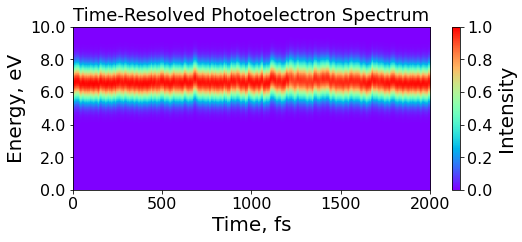

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 绘图
trpes.plot_trpes(time_bins, energy_grid, H_total, { })

# 添加标题
plt.title("Time-Resolved Photoelectron Spectrum", fontsize=18)

# 调整 x 轴范围到 0–2000，并设置刻度
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))  # 刻度从 0 到 2000，步长 500

# 保存为高清图片（白色背景、300 dpi）
plt.savefig(
    "trpes_highres.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    transparent=False
)

# 显示图像
plt.show()